In [10]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib # Para salvar os normalizadores
from tensorflow.keras import initializers
import os

In [11]:
def create_delta_data(local_data):
    OriginalData = pd.read_csv(local_data)
    OriginalData.index = (np.arange(0, len(OriginalData), 1).astype(float) * 0.07).round(5)
    OriginalData = OriginalData.drop(columns=["x(Wd,We)", "y(Wd,We)", "tempo"])
    theta = OriginalData["theta(Wd,We)"].to_numpy()
    theta_0 = theta[:-1]
    theta_1 = theta[1:]
    delta_theta = (theta_1 - theta_0) / 0.07
    wd_alinhado = OriginalData['Wd'].iloc[:-1]  
    we_alinhado = OriginalData['We'].iloc[:-1] 
    wd_true_alinhado = OriginalData['Wd_true'].iloc[:-1]
    we_true_alinhado = OriginalData['We_true'].iloc[:-1]
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta,
        'Wd_true': wd_true_alinhado,
        'We_true': we_true_alinhado
    })
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new

In [12]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       y_scaler,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    #restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We
            #x1_km1 = train_x[:, 0]  # Wd
            #x2_km1 = train_x[:, 1]  # We
            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys_real  = ((R / L) * (x1_km1 - x2_km1)) 

            phys_real = phys_real.reshape((-1, 1))  # shape [N-1, 1]
            phys_norm = y_scaler.transform(phys_real)
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys_norm))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % (epochs/5) == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }
    if plot:
        for split, m in metrics.items():
            print(f"\n{split} Metrics:")
            for k, v in m.items():
                print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

In [13]:
def create_sequences(input_data, target_data, timesteps):

    X_seq, Y_seq = [], []
    
    # Itera sobre os dados, começando após o número de timesteps
    for i in range(timesteps, len(input_data)):
        # A sequência de entrada (X_seq) é a janela de dados de i-timesteps até i
        X_seq.append(input_data[i-timesteps:i])
        
        # O alvo (Y_seq) é o valor de saída no passo de tempo atual 'i'
        Y_seq.append(target_data[i])
    
    return np.array(X_seq), np.array(Y_seq)

In [14]:
def Recontruir_Theta(model, inputs_norm, local_data_original, y_scaler):
    """
    Reconstrói o sinal de Theta a partir da previsão de sua derivada,
    e calcula o MSE de forma correta e alinhada.
    """

    Y_norm_pred = model.predict(inputs_norm)
    Y_pred_real = y_scaler.inverse_transform(Y_norm_pred) # Derivada na escala real

    DataOrigi = pd.read_csv(local_data_original)
    Theta_true = DataOrigi["theta(Wd,We)"].to_numpy()
    theta_reconstruido = np.zeros_like(Y_pred_real)
    theta_reconstruido[0] = Theta_true[0] + Y_pred_real[0] * 0.07


    for i in range(1, len(Y_pred_real)):
        # Fórmula da integração de Euler: y(t) = y(t-1) + y'(t) * dt
        theta_reconstruido[i] = theta_reconstruido[i-1] + Y_pred_real[i] * 0.07
    

    offset = len(Theta_true) - len(theta_reconstruido)
    Theta_true_alinhado = Theta_true[offset:]

    # O cálculo do MSE agora é feito entre dois vetores do mesmo tamanho.
    mse = np.mean(np.square(Theta_true_alinhado - theta_reconstruido))
    
    print(f"MSE entre Theta Original e Reconstruído: {mse:.4g}")

    # Plotando os dados alinhados
    plt.figure(figsize=(14, 6))
    plt.plot(Theta_true_alinhado, label='Theta Original (Alinhado)', color='orange', linestyle='--')
    plt.plot(theta_reconstruido, label='Theta Reconstruído', color='blue', alpha=0.8)
    plt.xlabel('Índice da Amostra (Alinhado)')
    plt.ylabel('Theta (rad)')
    plt.title('Comparação de Theta Reconstruído vs Original')
    plt.legend()
    plt.grid(True)
    plt.show() # Adicionado para exibir o gráfico
    
    return mse

def Aval_Thetha(model, time_steps, y_scaler):
    train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, time_steps)
    x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, time_steps)
    mse_train = Recontruir_Theta(model, train_x_seq, "./Dados/DataSmoothSpline1.csv", y_scaler)
    mse_val = Recontruir_Theta(model, x_val_seq, "./Dados/DataSmoothSpline2.csv", y_scaler)
    mse_test = Recontruir_Theta(model, x_test_seq, "./Dados/DataSmoothSpline3.csv", y_scaler)
    return [mse_train, mse_val, mse_test]

In [15]:
def CreateModel(input_size = 2, output_size = 1, units = 10, units2 = 5,time_steps = 2, 
                n_seed = [32, 67, 90, 546, 801], lam_1 = 1.0, lam_2 = 0.0, lr = 0.01, l2 = 0.8):
    """
    Cria um modelo Sequential com uma camada RNN e uma camada Dense.

    """
    train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, time_steps)
    x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, time_steps)
    
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(units, return_sequences=False, input_shape=[time_steps, input_size],
                               kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[0])),
                               recurrent_initializer=initializers.Orthogonal(seed=int(n_seed[1])),
                               bias_initializer=initializers.RandomNormal(seed=int(n_seed[2])),
                               kernel_regularizer= keras.regularizers.l2(l2)),
        keras.layers.Dense(units2, activation = 'tanh',kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[3])),
                           bias_initializer=initializers.RandomNormal(seed=int(n_seed[4]))),
        keras.layers.Dense(output_size,
        kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[5])),
        bias_initializer=initializers.RandomNormal(seed=int(n_seed[6])))
    ])

    metrics = custom_train_model_with_es_physics(model,
                                       train_x = train_x_seq, train_y = train_y_seq,
                                       x_val = x_val_seq, y_val = y_val_seq,
                                       x_test = x_test_seq, y_test = y_test_seq,
                                       restrictions_data = Restrictions_data[:-time_steps,:],
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_scaler= y_scaler,
                                       lambda1= lam_1, lambda2=lam_2,
                                       epochs = 10000, patience=500,
                                       min_delta=0, plot=False,
                                       learning_rate= lr, use_early_stopping=True)

    
    return model, metrics

In [16]:
def Generate_Random_Models(units=10,units2 = 5, time_steps=2, lam_1=0.5, lam_2=0.5, lr = 0.001, aval= True, l2 = 0.8):
    """
    Treina vários modelos com seeds e learning rates aleatórios,
    retornando o melhor modelo encontrado com base no MSE de teste.
    """
    best_test_mse = float('inf')
    best_test_r2 = None
    best_model = None
    best_metrics = None

    for i in range(10):
        # Seed aleatória
        np_seed = np.random.randint(1, 10000, size = 7)


        print(f"Modelo {i+1}: unidades = {units}, seed = {np_seed}, lr = {lr:.5f}")

        # Criação e treino do modelo
        model, metrics = CreateModel(
            units=units,
            units2=units2,
            time_steps=time_steps,
            lam_1=lam_1,
            lam_2=lam_2,
            n_seed=np_seed,
            lr=lr,
            l2 = l2
        )

        # Métricas do teste
        test_mse = metrics['Test']['MSE']
        if test_mse < best_test_mse:
            best_test_mse = test_mse
            best_model = model
            best_test_r2 = metrics['Test']['R2']
            best_metrics = metrics
            print(f"Novo melhor modelo: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, lr = {lr:.5f}")

    print(f"\nMelhor modelo final: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, unidades = {units},  lr = {lr:.5f}")
    if aval:
        Aval_Thetha(best_model, time_steps, y_scaler)

    return best_model, best_metrics


In [17]:
TrainData = create_delta_data("./Dados/DataSmoothSpline1.csv")
TestData = create_delta_data("./Dados/DataSmoothSpline3.csv")
ValData = create_delta_data("./Dados/DataSmoothSpline2.csv")

# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"
RESTRICTIONS = ["Wd_true", "We_true"]


Restrictions_data = TrainData[RESTRICTIONS].to_numpy()

print("\nShape de Restrictions_data:", Restrictions_data.shape)
print("Primeiras linhas de Restrictions_data:\n", Restrictions_data[:5])

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()


x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(-1, 1))

print("\nAjustando os normalizadores (scalers) com os dados de treino...")
x_scaler.fit(train_x)
y_scaler.fit(train_y)

joblib.dump(x_scaler, 'x_scaler.gz')
joblib.dump(y_scaler, 'y_scaler.gz')
print("Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'")

# AGORA, TRANSFORME TODOS OS CONJUNTOS DE DADOS com os scalers já ajustados
train_x_norm = x_scaler.transform(train_x)
train_y_norm = y_scaler.transform(train_y)

x_val_norm = x_scaler.transform(x_val)
y_val_norm = y_scaler.transform(y_val)

x_test_norm = x_scaler.transform(x_test)
y_test_norm = y_scaler.transform(y_test)

restric_norm = x_scaler.transform(Restrictions_data)
print("\nShape de Restrictions_data normalizado:", restric_norm.shape)

print("\nShape de X_train depois da normalização:", train_x_norm.shape)
print("Primeiras linhas de X_train normalizado:\n", train_x_norm[:5])
print("\nPrimeiras linhas de y_train normalizado:\n", train_y_norm[:5])


            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  

In [18]:
# Cria uma pasta para salvar os modelos, se não existir
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Inicializa uma lista para armazenar os resultados
results_list = []

# Laço principal de treinamento
for neurons in range(10, 21,1):
    units2 = np.random.randint(1,neurons)
    print(f"\nIniciando testes com {neurons} neurônios...")
    for time_steps in range(3, 5):
        for l2 in [0.1, 0.9]:
            print(f"  Treinando: Neurônios1={neurons},Neurônios2={units2} Timesteps={time_steps}, L2={l2}")
            
            # Treina o modelo para a configuração atual
            best_model, best_metrics = Generate_Random_Models(
                units=neurons,
                units2=units2, 
                time_steps=time_steps, 
                l2=l2,
                lam_1=0.5,
                lam_2=0.5,
                lr=0.01,
                aval=False
            )
            
            # Define um nome de arquivo único e salva o modelo
            model_filename = f"saved_models/model_U{neurons}_U2{units2}_TS{time_steps}_L2-{l2}.keras"
            best_model.save(model_filename)

            # Cria um registro com os resultados
            result_entry = {
                'neurons': neurons,
                'neuros2':units2,
                'time_steps': time_steps,
                'l2_factor': l2,
                'model_file': model_filename,
                'R2_Train': best_metrics['Training']['R2'],
                'MSE_Train': best_metrics['Training']['MSE'],
                'R2_Validation': best_metrics['Validation']['R2'],
                'MSE_Validation': best_metrics['Validation']['MSE'],
                'R2_Test': best_metrics['Test']['R2'],
                'MSE_Test': best_metrics['Test']['MSE']
            }
            
            # Adiciona o registro à lista
            results_list.append(result_entry)

print("\nTreinamento concluído.")

# Converte a lista de resultados em um DataFrame do pandas
results_df = pd.DataFrame(results_list)

# Ordena o DataFrame pelo R2 de Teste (melhores primeiro)
results_df = results_df.sort_values(by='R2_Test', ascending=False)

# Salva o DataFrame em um arquivo CSV
results_df.to_csv('model_training_results.csv', index=False)

print("Planilha 'model_training_results.csv' salva com sucesso!")
print("\n--- 5 Melhores Modelos Encontrados ---")
print(results_df.head(5))


Iniciando testes com 10 neurônios...
  Treinando: Neurônios1=10,Neurônios2=5 Timesteps=3, L2=0.1
Modelo 1: unidades = 10, seed = [6090  591 5432 9950 7419 2396 3034], lr = 0.01000
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0.5, λ2=0.5


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1: Loss=0.3918, MSE_d=0.3866, MSE_f=0.3969, Val MSE=0.2776
Epoch 2000: Loss=0.003641, MSE_d=0.002811, MSE_f=0.00447, Val MSE=0.02552
Early stopping na época 2323
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Novo melhor modelo: MSE = 0.01563, R2 = 0.7124, lr = 0.01000
Modelo 2: unidades = 10, seed = [9171 9216  331 9263 4083  844 5436], lr = 0.01000
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0.5, λ2=0.5
Epoch 1: Loss=0.3417, MSE_d=0.3364, MSE_f=0.3469, Val MSE=0.1556


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 2000: Loss=0.003864, MSE_d=0.003386, MSE_f=0.004342, Val MSE=0.01692
Early stopping na época 2104
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Modelo 3: unidades = 10, seed = [2489 6213 8690 6475 9580 1843 6451], lr = 0.01000
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0.5, λ2=0.5
Epoch 1: Loss=0.2494, MSE_d=0.2524, MSE_f=0.2464, Val MSE=0.1719


...

Epoch 2000: Loss=0.005823, MSE_d=0.004389, MSE_f=0.007257, Val MSE=0.01252
Early stopping na época 2514
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Novo melhor modelo: MSE = 0.01202, R2 = 0.779, lr = 0.01000
Modelo 9: unidades = 20, seed = [2920 9792 3572 2162 9346 7076 9749], lr = 0.01000
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0.5, λ2=0.5
Epoch 1: Loss=0.487, MSE_d=0.4889, MSE_f=0.4851, Val MSE=0.1591


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 1533
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Modelo 10: unidades = 20, seed = [2891 8846 2065 5339 5594 4649 1300], lr = 0.01000
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0.5, λ2=0.5
Epoch 1: Loss=0.09842, MSE_d=0.09465, MSE_f=0.1022, Val MSE=0.4068


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 942
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Melhor modelo final: MSE = 0.01202, R2 = 0.779, unidades = 20,  lr = 0.01000

Treinamento concluído.
Planilha 'model_training_results.csv' salva com sucesso!

--- 5 Melhores Modelos Encontrados ---
    neurons  neuros2  time_steps  l2_factor  \
21       15        4           3        0.9   
35       18       14           4        0.9   
14       13        8           4        0.1   
41       20       17           3        0.9   
26       16       15           4        0.1   

                                      model_file  R2_Train  MSE_Train  \
21   saved_models/model_U15_U24_TS3_L2-0.9.keras  0.925813   0.005721   
35  saved_models/model_U18_U214_TS4_L2-0.9.keras  0.932283   0.005224   
14   saved_models/model_U13_U28_TS4_L2-0.1.keras  0.932417   0.005214   
41  saved_models/model_U20_U217_TS3_L2-0.9.keras  0.927653   0.005579   
26  s


--- Carregando o melhor modelo ---
Melhor modelo a ser carregado: saved_models/model_U15_U24_TS3_L2-0.9.keras
Métricas de Teste do melhor modelo (R2): 0.8042
Métricas de Teste do melhor modelo (MSE): 0.01064

Modelo carregado com sucesso!

--- Avaliando o melhor modelo ---
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MSE entre Theta Original e Reconstruído: 0.4209


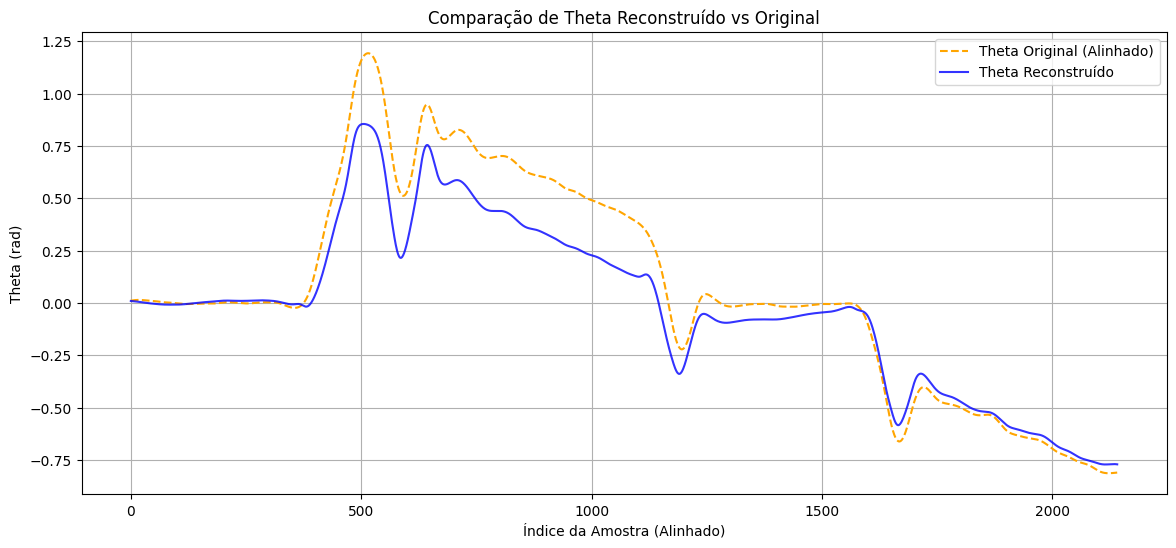

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE entre Theta Original e Reconstruído: 0.344


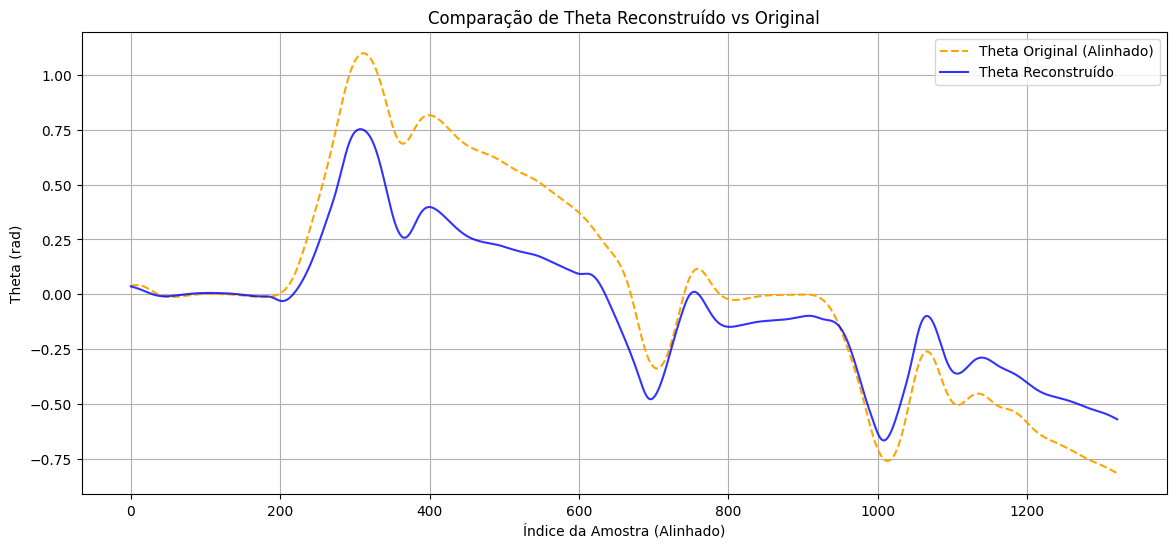

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE entre Theta Original e Reconstruído: 0.2208


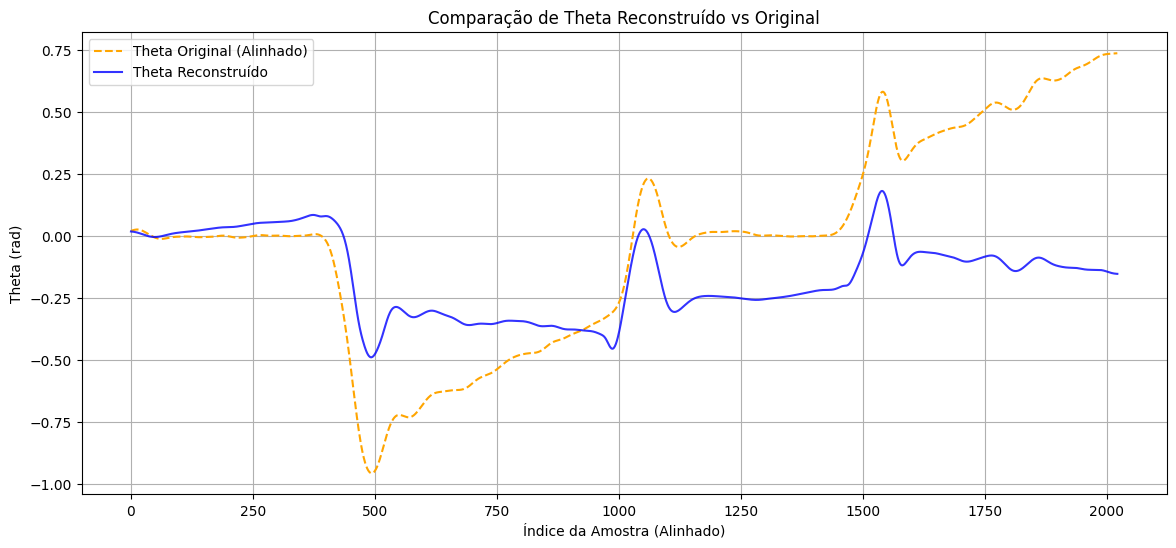

In [19]:

try:
    results_df = pd.read_csv('model_training_results.csv')
except FileNotFoundError:
    print("Erro: O arquivo 'model_training_results.csv' não foi encontrado. Certifique-se de que o treinamento foi executado.")
else:
    # 2. Encontre o melhor modelo
    # Como o DataFrame já está ordenado, o primeiro registro é o melhor
    best_model_row = results_df.iloc[0]
    best_model_path = best_model_row['model_file']

    print("\n--- Carregando o melhor modelo ---")
    print(f"Melhor modelo a ser carregado: {best_model_path}")
    print(f"Métricas de Teste do melhor modelo (R2): {best_model_row['R2_Test']:.4g}")
    print(f"Métricas de Teste do melhor modelo (MSE): {best_model_row['MSE_Test']:.4g}")
    
    # 3. Carregue o modelo
    try:
        # A função load_model carrega o modelo salvo
        best_model = keras.models.load_model(best_model_path)
        print("\nModelo carregado com sucesso!")
        
        # Opcional: verifique a estrutura do modelo
        # best_model.summary()
        
    except FileNotFoundError:
        print(f"Erro: O arquivo do modelo '{best_model_path}' não foi encontrado.")

# Avaliação do melhor modelo
if 'best_model' in locals():
    print("\n--- Avaliando o melhor modelo ---")
    Aval_Thetha(best_model, time_steps=int(best_model_row['time_steps']), y_scaler=y_scaler)    